# Phase 5: Expanded Deductive Hypothesis Testing
## 2026 Bangladesh National Election & July Charter Referendum

This notebook implements 10 highly specific partisan hypotheses exploring the deep socio-economic and generational divides of the 2026 election and the concurrent constitutional reform referendum.

**Methodology**: Apache Spark MLlib (GBT, Logistic Regression, Linear Regression, Correlation) and statistical threshold detection.


### Environment Setup and Global Configuration
Ensure PySpark is installed and initialize the Spark session. We configure the standard visualization palette for academic plotting.


In [ ]:
!pip install pyspark -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType

from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import GBTClassifier, LogisticRegression
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml import Pipeline

spark = SparkSession.builder.appName("Phase5_10_Hypotheses").getOrCreate()

plt.rcParams.update({
    'figure.figsize': (12, 7), 'figure.dpi': 120,
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.grid': True, 'grid.alpha': 0.3,
    'legend.fontsize': 10,
})

PALETTE_BNP = '#1B5E20'
PALETTE_JAMAAT = '#B71C1C'
PALETTE_ACCENT = '#1565C0'
PALETTE_NEUTRAL = '#37474F'

print("Environment setup complete.")

Environment setup complete.


### Data Loading & Base Preparation
We assume `grand_df_enriched` is available in the environment. We filter out independents to create the binary classification dataset `clf_df` for the BNP vs Jamaat/Reform contest, and train a baseline GBT model to extract median feature values for Partial Dependence Plots (PDPs).


In [ ]:
# Load data (Modify path if running independently)
try:
    grand_df_enriched
except NameError:
    # If not in memory, load from CSV
    grand_df_enriched = spark.read.csv("grand_df_enriched.csv", header=True, inferSchema=True)

PHASE5_FEATURES = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "First_Time_Voter_Pct",
    "NEET_Youth_Pct", "Female_Pop_Pct", "Pucca_Pct", "Extreme_Poverty_Pct",
    "WPI_Log", "Organized_Learning_Pct", "Sanitation_Pct", "Electricity_Pct",
    "Clean_Fuel_Pct", "Internet_Pct", "Financial_Inclusion_Pct",
    "Digital_Youth_Index", "Urban_Proxy", "Infrastructure_Composite",
    "Deprivation_Index"
]

# Create binary classification dataframe
clf_df = grand_df_enriched.filter(F.col("Coalition").isin(["BNP_COALITION", "JAMAAT_REFORM"]))

# FIX: Fit the model once, extract labels, then transform
indexer = StringIndexer(inputCol="Coalition", outputCol="label")
indexer_model = indexer.fit(clf_df)
label_mapping = indexer_model.labels
clf_df = indexer_model.transform(clf_df)

jamaat_idx = label_mapping.index("JAMAAT_REFORM")
bnp_idx = label_mapping.index("BNP_COALITION")

# Pre-compute Pandas dataframe and medians for PDPs
clf_pdf = clf_df.toPandas()
for f in PHASE5_FEATURES:
    clf_pdf[f] = pd.to_numeric(clf_pdf[f], errors='coerce')
    clf_df = clf_df.withColumn(f, F.col(f).cast(DoubleType()))

median_vals = {f: float(clf_pdf[f].median()) for f in PHASE5_FEATURES}

# Train baseline GBT for general PDP extraction
assembler = VectorAssembler(inputCols=PHASE5_FEATURES, outputCol="features", handleInvalid="skip")
gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=100, maxDepth=5, seed=488)
pipe = Pipeline(stages=[assembler, gbt])
gbt_base_model = pipe.fit(clf_df)

print(f"Prepared {clf_df.count()} constituencies for partisan hypothesis testing.")


Prepared 263 constituencies for partisan hypothesis testing.


## Hypothesis 1: The Elite/Wealth Reversal
**Premise**: Wealthier demographics (High `Pucca_Pct` / High `Wealth_Polarization_Index`) unexpectedly preferred the Jamaat/NCP reform coalition, challenging the assumption that reformist parties primarily appeal to the rural poor.
**Methodology**: Quintile-binned analysis on `Pucca_Pct` and `WPI_Log`, followed by 1D Partial Dependence Plot (PDP) extraction from the GBT Classifier to verify monotonic increases in Jamaat probability.


H1: THE ELITE/WEALTH REVERSAL
Jamaat Win Rate by Pucca_Pct Quintile:
Pucca_Quintile
Q1(Low)     37.735849
Q2          21.153846
Q3          15.094340
Q4          25.000000
Q5(High)    37.735849
dtype: float64


/tmp/ipykernel_3883/1965176357.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pucca_rates = clf_pdf.groupby('Pucca_Quintile', observed=False).apply(lambda x: (x['Coalition'] == 'JAMAAT_REFORM').mean() * 100)
/tmp/ipykernel_3883/1965176357.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wpi_rates = clf_pdf.groupby('WPI_Quintile', observed=False).apply(lambda x: (x['Coalition'] == 'JAMAAT_REFORM').m

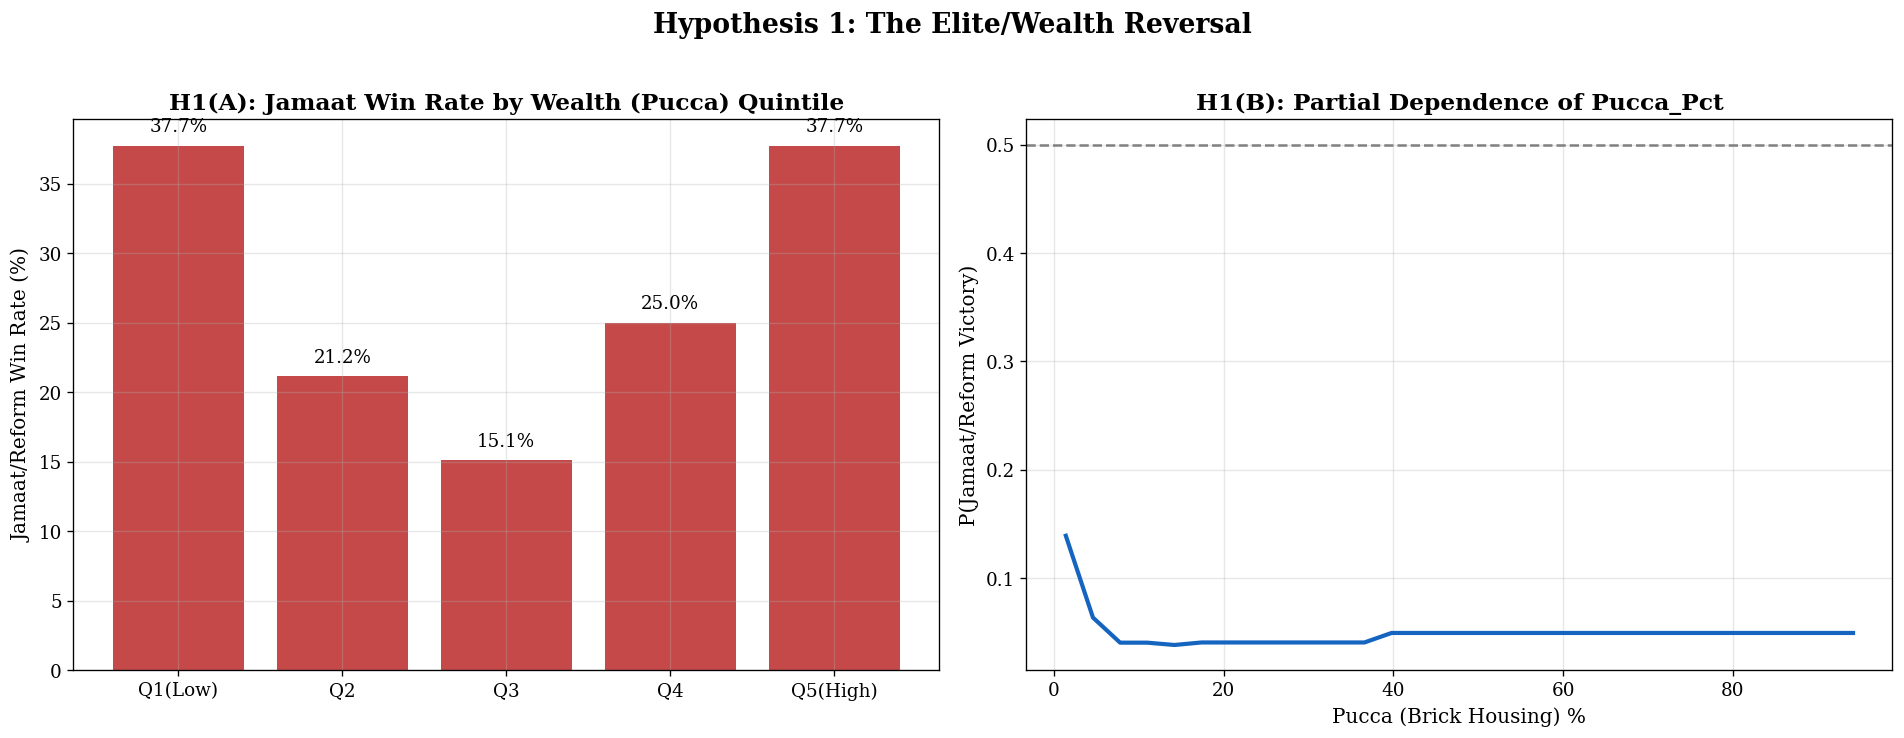

In [ ]:
print("=" * 80)
print("H1: THE ELITE/WEALTH REVERSAL")
print("=" * 80)

# 1. Quintile Analysis
clf_pdf['Pucca_Quintile'] = pd.qcut(clf_pdf['Pucca_Pct'], 5, labels=['Q1(Low)', 'Q2', 'Q3', 'Q4', 'Q5(High)'])
clf_pdf['WPI_Quintile'] = pd.qcut(clf_pdf['WPI_Log'], 5, labels=['Q1(Low)', 'Q2', 'Q3', 'Q4', 'Q5(High)'])

pucca_rates = clf_pdf.groupby('Pucca_Quintile', observed=False).apply(lambda x: (x['Coalition'] == 'JAMAAT_REFORM').mean() * 100)
wpi_rates = clf_pdf.groupby('WPI_Quintile', observed=False).apply(lambda x: (x['Coalition'] == 'JAMAAT_REFORM').mean() * 100)

print("Jamaat Win Rate by Pucca_Pct Quintile:")
print(pucca_rates)

# 2. Partial Dependence
pucca_range = np.linspace(clf_pdf["Pucca_Pct"].min(), clf_pdf["Pucca_Pct"].max(), 30)
pd_pucca = []
for val in pucca_range:
    row = {f: median_vals[f] for f in PHASE5_FEATURES}
    row["Pucca_Pct"] = float(val)
    temp_df = spark.createDataFrame([row])
    for c in PHASE5_FEATURES: temp_df = temp_df.withColumn(c, F.col(c).cast(DoubleType()))
    prob = gbt_base_model.transform(temp_df).select("probability").head()[0]
    pd_pucca.append(prob[jamaat_idx])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bars = ax.bar(pucca_rates.index, pucca_rates.values, color=PALETTE_JAMAAT, alpha=0.8)
ax.set_ylabel("Jamaat/Reform Win Rate (%)")
ax.set_title("H1(A): Jamaat Win Rate by Wealth (Pucca) Quintile")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', ha='center')

ax = axes[1]
ax.plot(pucca_range, pd_pucca, color=PALETTE_ACCENT, linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_xlabel("Pucca (Brick Housing) %")
ax.set_ylabel("P(Jamaat/Reform Victory)")
ax.set_title("H1(B): Partial Dependence of Pucca_Pct")

plt.suptitle("Hypothesis 1: The Elite/Wealth Reversal", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Hypothesis 2: The Senior Citizen Firewall
**Premise**: A high `Senior_Electorate_Pct` acts as an absolute demographic stronghold for the BNP, categorically rejecting the Jamaat/NCP alliance.
**Methodology**: Welch's t-test comparing `Senior_Electorate_Pct` across coalitions and a 1D Partial Dependence Plot (PDP) to visualize the exact stabilization threshold.


H2: THE SENIOR CITIZEN FIREWALL
BNP Mean Senior Pct: 13.22%
Jamaat Mean Senior Pct: 13.77%
t-statistic: -1.5284, p-value: 0.128900


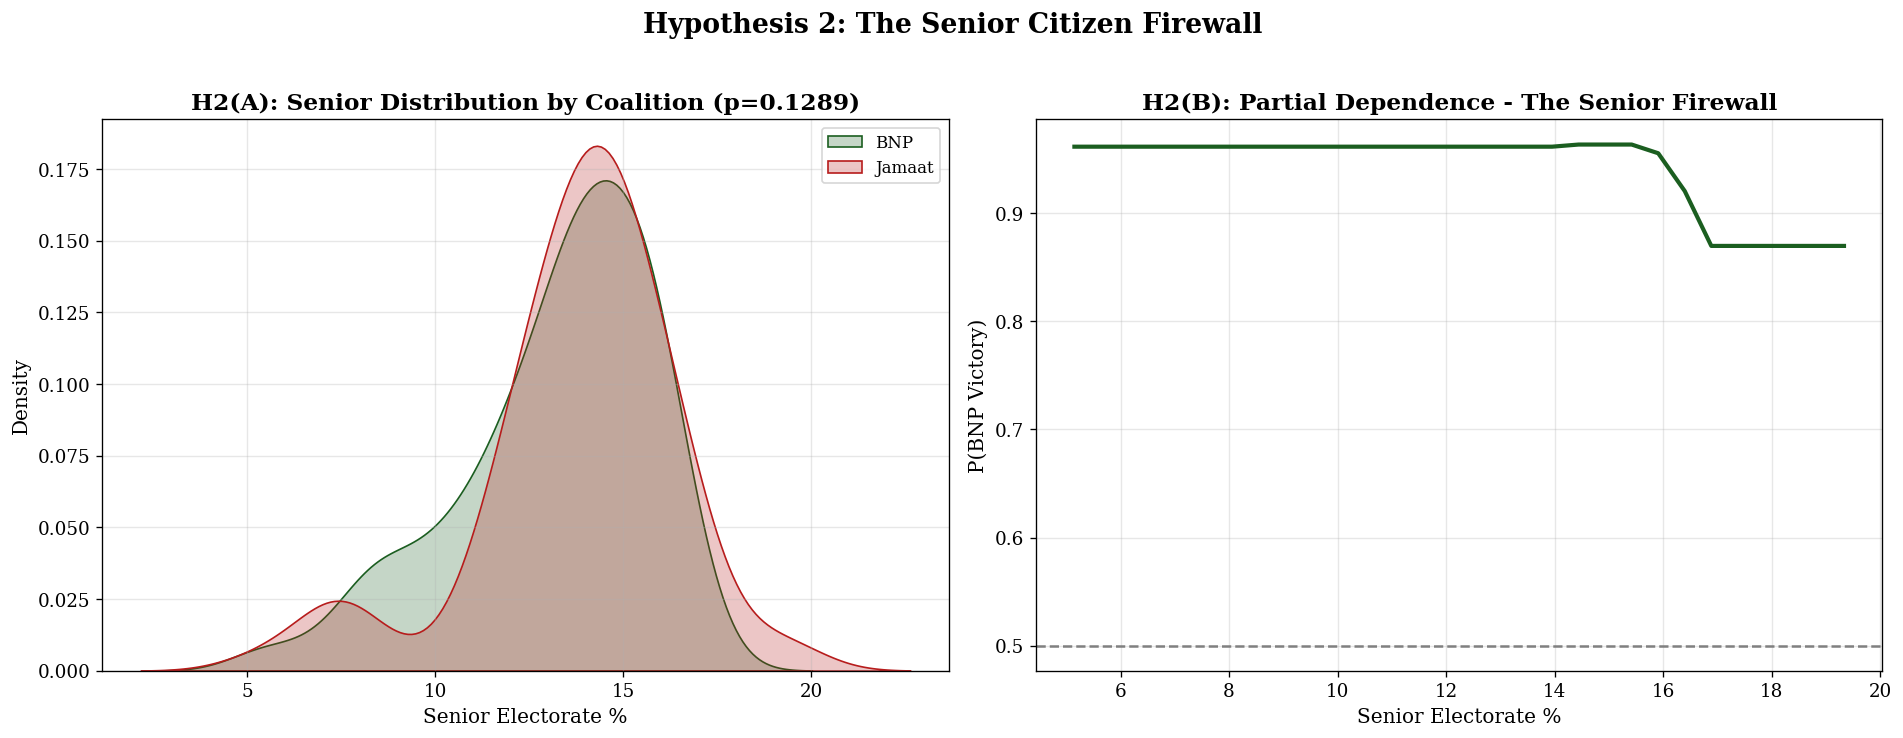

In [ ]:
print("=" * 80)
print("H2: THE SENIOR CITIZEN FIREWALL")
print("=" * 80)

# 1. Welch's T-Test
bnp_senior = clf_pdf[clf_pdf["Coalition"] == "BNP_COALITION"]["Senior_Electorate_Pct"].dropna()
jam_senior = clf_pdf[clf_pdf["Coalition"] == "JAMAAT_REFORM"]["Senior_Electorate_Pct"].dropna()
t_stat, p_val = stats.ttest_ind(bnp_senior, jam_senior, equal_var=False)

print(f"BNP Mean Senior Pct: {bnp_senior.mean():.2f}%")
print(f"Jamaat Mean Senior Pct: {jam_senior.mean():.2f}%")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")

# 2. Partial Dependence
senior_range = np.linspace(clf_pdf["Senior_Electorate_Pct"].min(), clf_pdf["Senior_Electorate_Pct"].max(), 30)
pd_senior = []
for val in senior_range:
    row = {f: median_vals[f] for f in PHASE5_FEATURES}
    row["Senior_Electorate_Pct"] = float(val)
    temp_df = spark.createDataFrame([row])
    for c in PHASE5_FEATURES: temp_df = temp_df.withColumn(c, F.col(c).cast(DoubleType()))
    prob = gbt_base_model.transform(temp_df).select("probability").head()[0]
    pd_senior.append(prob[bnp_idx])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.kdeplot(bnp_senior, color=PALETTE_BNP, fill=True, label="BNP", ax=ax)
sns.kdeplot(jam_senior, color=PALETTE_JAMAAT, fill=True, label="Jamaat", ax=ax)
ax.set_xlabel("Senior Electorate %")
ax.set_title(f"H2(A): Senior Distribution by Coalition (p={p_val:.4f})")
ax.legend()

ax = axes[1]
ax.plot(senior_range, pd_senior, color=PALETTE_BNP, linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_xlabel("Senior Electorate %")
ax.set_ylabel("P(BNP Victory)")
ax.set_title("H2(B): Partial Dependence - The Senior Firewall")

plt.suptitle("Hypothesis 2: The Senior Citizen Firewall", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Hypothesis 3: The Student/Youth Vanguard
**Premise**: Constituencies with high `Organized_Learning_Pct` (students) and high `Youth_Electorate_Pct` overwhelmingly rejected the BNP in favor of the Jamaat/NCP alliance.
**Methodology**: Interaction feature engineering (`Student_Vanguard_Index`) and conditional threshold detection.


H3: THE STUDENT/YOUTH VANGUARD
Student_Vanguard_Index Feature Importance: 0.0659


/tmp/ipykernel_3883/2788391473.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vanguard_rates = clf_pdf.groupby("Vanguard_Level").apply(lambda x: (x["Coalition"] == "JAMAAT_REFORM").mean() * 100)


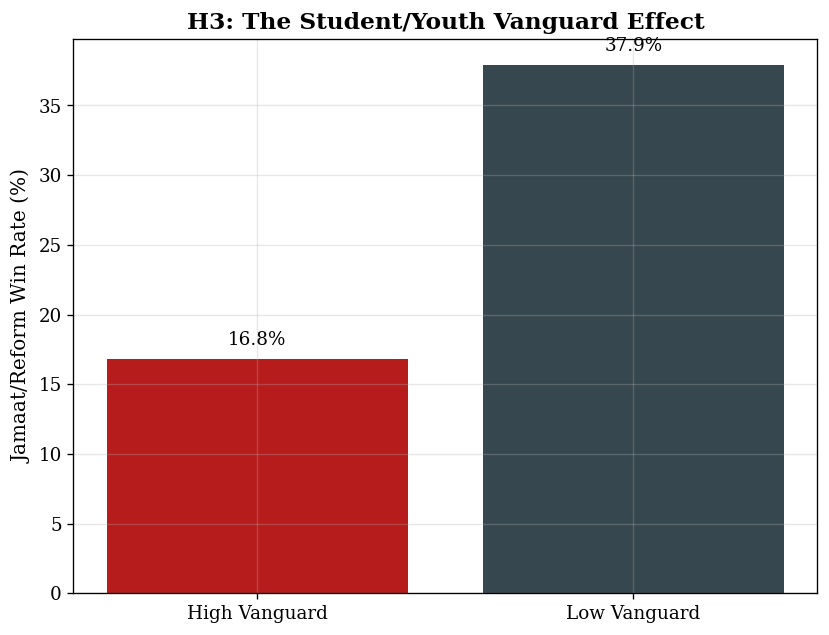

In [ ]:
print("=" * 80)
print("H3: THE STUDENT/YOUTH VANGUARD")
print("=" * 80)

clf_df_h3 = clf_df.withColumn("Student_Vanguard_Index", F.col("Organized_Learning_Pct") * F.col("Youth_Electorate_Pct"))
features_h3 = PHASE5_FEATURES + ["Student_Vanguard_Index"]

assembler_h3 = VectorAssembler(inputCols=features_h3, outputCol="features_h3", handleInvalid="skip")
gbt_h3 = GBTClassifier(featuresCol="features_h3", labelCol="label", maxIter=50, maxDepth=4, seed=488)
pipe_h3 = Pipeline(stages=[assembler_h3, gbt_h3])
model_h3 = pipe_h3.fit(clf_df_h3)

importances = model_h3.stages[-1].featureImportances.toArray()
vanguard_imp = importances[features_h3.index("Student_Vanguard_Index")]
print(f"Student_Vanguard_Index Feature Importance: {vanguard_imp:.4f}")

clf_pdf["Student_Vanguard_Index"] = clf_pdf["Organized_Learning_Pct"] * clf_pdf["Youth_Electorate_Pct"]
med_vanguard = clf_pdf["Student_Vanguard_Index"].median()
clf_pdf["Vanguard_Level"] = np.where(clf_pdf["Student_Vanguard_Index"] > med_vanguard, "High Vanguard", "Low Vanguard")

vanguard_rates = clf_pdf.groupby("Vanguard_Level").apply(lambda x: (x["Coalition"] == "JAMAAT_REFORM").mean() * 100)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(vanguard_rates.index, vanguard_rates.values, color=[PALETTE_JAMAAT, PALETTE_NEUTRAL])
ax.set_ylabel("Jamaat/Reform Win Rate (%)")
ax.set_title("H3: The Student/Youth Vanguard Effect")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', ha='center')
plt.show()

## Hypothesis 4: The Referendum Generational Chasm
**Premise**: The concurrent "July Charter" referendum experienced a severe generational divide. Senior citizens systematically voted "NO", while the youth voted "YES".
**Methodology**: Pearson correlations and a multivariate `LinearRegression` predicting `YES_Pct` using generational demographics.


H4: THE REFERENDUM GENERATIONAL CHASM
Constituencies with Referendum Data: 168
Correlation (Senior vs NO_Pct): 0.0062
Correlation (Youth vs YES_Pct): -0.0341
Regression Coeffs predicting YES_Pct -> Senior: -0.3407, Youth: -0.2537


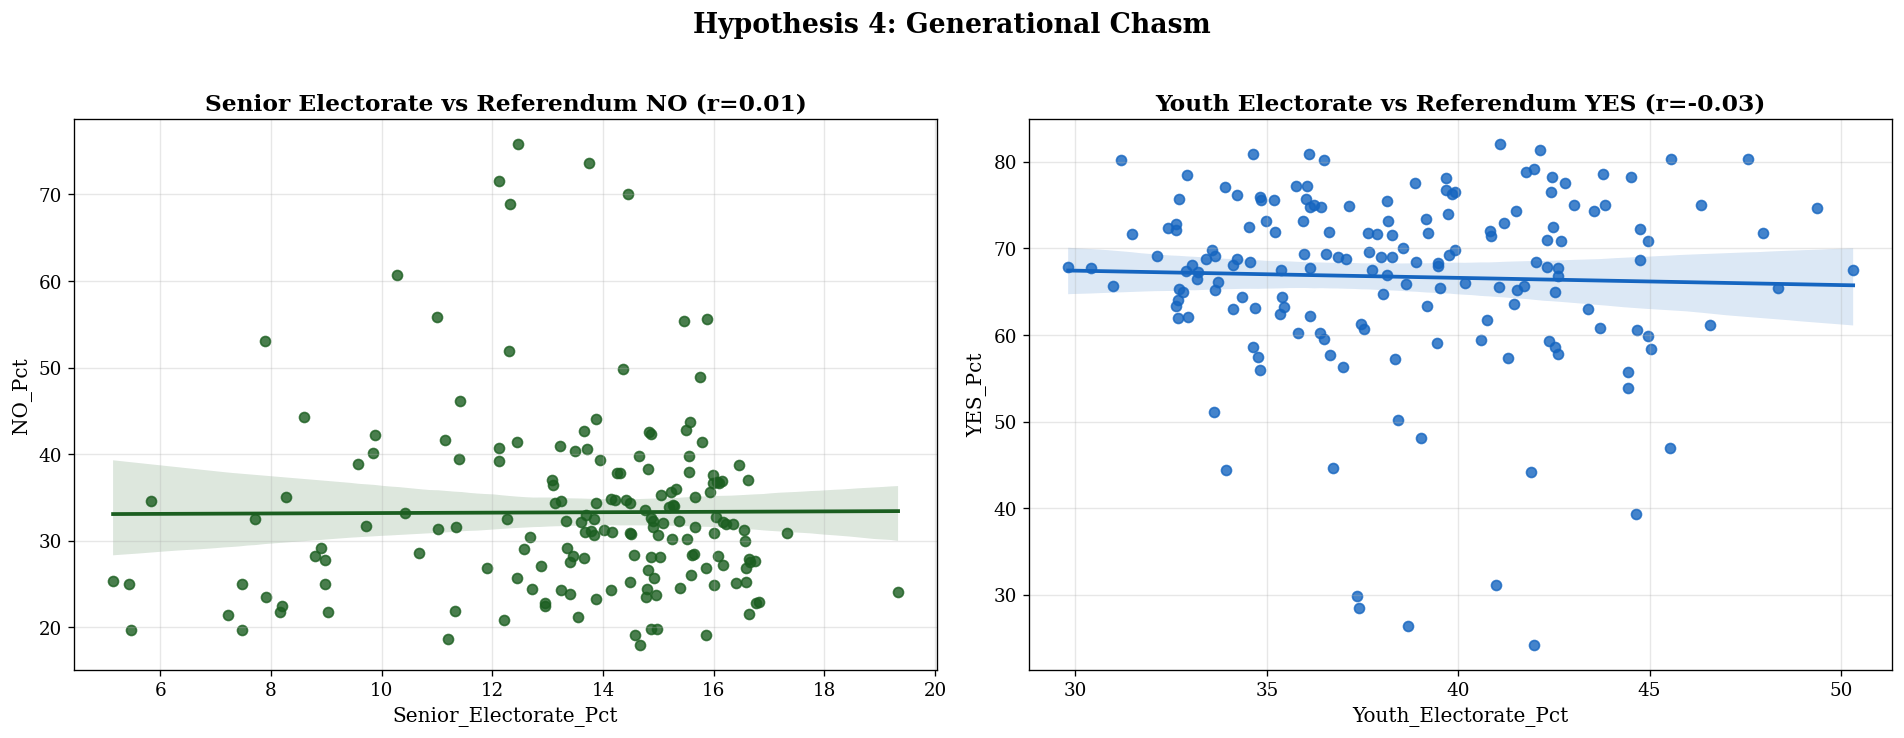

In [ ]:
print("=" * 80)
print("H4: THE REFERENDUM GENERATIONAL CHASM")
print("=" * 80)

ref_df = grand_df_enriched.select("Constituency", "Senior_Electorate_Pct", "Youth_Electorate_Pct", "YES_Pct", "NO_Pct").dropna()
print(f"Constituencies with Referendum Data: {ref_df.count()}")

ref_pdf = ref_df.toPandas()
corr_senior_no = ref_pdf["Senior_Electorate_Pct"].corr(ref_pdf["NO_Pct"])
corr_youth_yes = ref_pdf["Youth_Electorate_Pct"].corr(ref_pdf["YES_Pct"])

print(f"Correlation (Senior vs NO_Pct): {corr_senior_no:.4f}")
print(f"Correlation (Youth vs YES_Pct): {corr_youth_yes:.4f}")

# Linear Regression
assembler_h4 = VectorAssembler(inputCols=["Senior_Electorate_Pct", "Youth_Electorate_Pct"], outputCol="features_h4")
lr_h4 = LinearRegression(featuresCol="features_h4", labelCol="YES_Pct")
pipe_h4 = Pipeline(stages=[assembler_h4, lr_h4])
lr_model = pipe_h4.fit(ref_df)

coeffs = lr_model.stages[-1].coefficients
print(f"Regression Coeffs predicting YES_Pct -> Senior: {coeffs[0]:.4f}, Youth: {coeffs[1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(data=ref_pdf, x="Senior_Electorate_Pct", y="NO_Pct", color=PALETTE_BNP, ax=axes[0])
axes[0].set_title(f"Senior Electorate vs Referendum NO (r={corr_senior_no:.2f})")
sns.regplot(data=ref_pdf, x="Youth_Electorate_Pct", y="YES_Pct", color=PALETTE_ACCENT, ax=axes[1])
axes[1].set_title(f"Youth Electorate vs Referendum YES (r={corr_youth_yes:.2f})")
plt.suptitle("Hypothesis 4: Generational Chasm", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Hypothesis 5: The Gender Partisan Divide
**Premise**: Higher `Female_Pop_Pct` strongly correlates with BNP Coalition victories.
**Methodology**: GBT Feature Importance and Quadrant Analysis.


H5: THE GENDER PARTISAN DIVIDE
Female_Pop_Pct Feature Importance: 0.0469


/tmp/ipykernel_3883/133143072.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_rates = clf_pdf.groupby("Female_Level").apply(lambda x: (x["Coalition"] == "BNP_COALITION").mean() * 100)


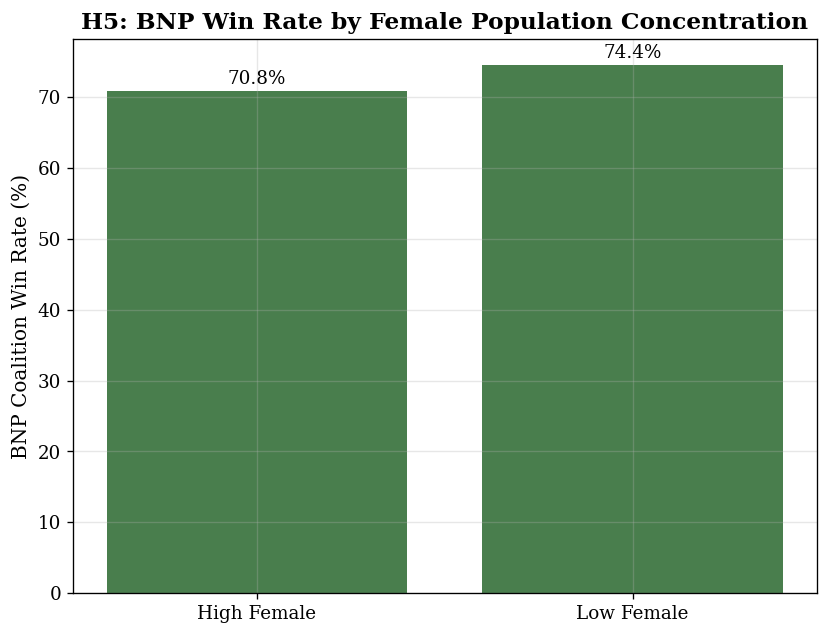

In [ ]:
print("=" * 80)
print("H5: THE GENDER PARTISAN DIVIDE")
print("=" * 80)

female_imp = gbt_base_model.stages[-1].featureImportances[PHASE5_FEATURES.index("Female_Pop_Pct")]
print(f"Female_Pop_Pct Feature Importance: {female_imp:.4f}")

med_female = clf_pdf["Female_Pop_Pct"].median()
clf_pdf["Female_Level"] = np.where(clf_pdf["Female_Pop_Pct"] > med_female, "High Female", "Low Female")

gender_rates = clf_pdf.groupby("Female_Level").apply(lambda x: (x["Coalition"] == "BNP_COALITION").mean() * 100)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(gender_rates.index, gender_rates.values, color=PALETTE_BNP, alpha=0.8)
ax.set_ylabel("BNP Coalition Win Rate (%)")
ax.set_title("H5: BNP Win Rate by Female Population Concentration")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', ha='center')
plt.show()

## Hypothesis 6: The Digital Battleground
**Premise**: Higher `Internet_Pct` heavily favors the Jamaat/NCP coalition, reflecting their successful digital campaigns.
**Methodology**: Turnout-controlled GBT partial dependence for purely partisan effect.


H6: THE DIGITAL BATTLEGROUND
Internet_Pct Importance (Controlling for Turnout): 0.0117


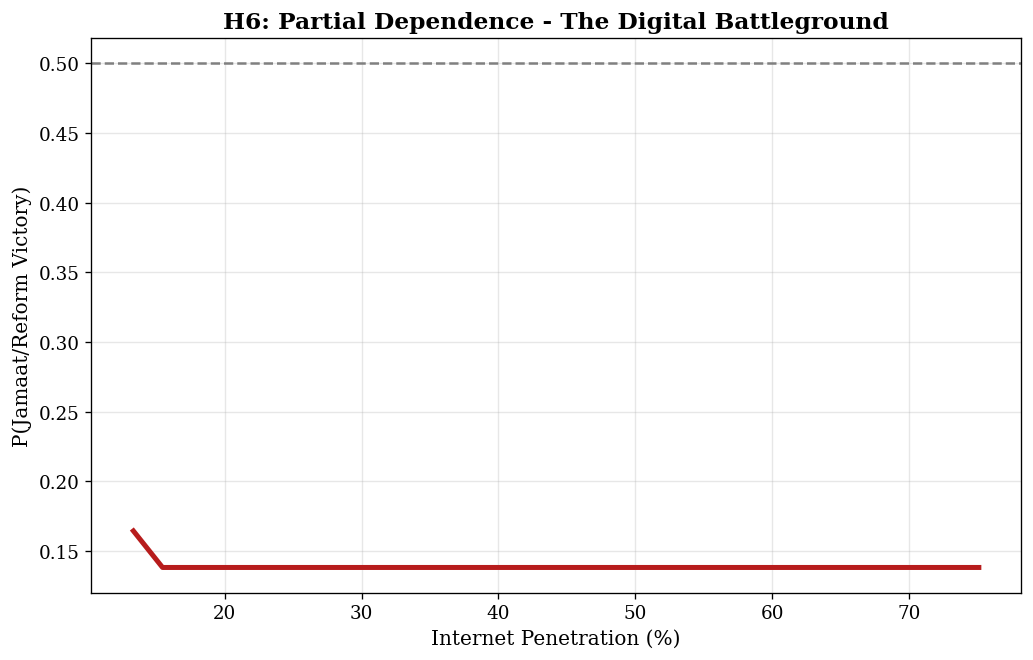

In [ ]:
print("=" * 80)
print("H6: THE DIGITAL BATTLEGROUND")
print("=" * 80)

# Turnout-controlled GBT
features_tc = PHASE5_FEATURES + ["Voter_Turnout_Pct"]
clf_df_tc = grand_df_enriched.filter(F.col("Coalition").isin(["BNP_COALITION", "JAMAAT_REFORM"])).dropna(subset=features_tc)
clf_df_tc = indexer.fit(clf_df_tc).transform(clf_df_tc)

for c in features_tc: clf_df_tc = clf_df_tc.withColumn(c, F.col(c).cast(DoubleType()))

assembler_tc = VectorAssembler(inputCols=features_tc, outputCol="features_tc", handleInvalid="skip")
gbt_tc = GBTClassifier(featuresCol="features_tc", labelCol="label", maxIter=50, maxDepth=4, seed=488)
pipe_tc = Pipeline(stages=[assembler_tc, gbt_tc])
model_tc = pipe_tc.fit(clf_df_tc)

internet_imp = model_tc.stages[-1].featureImportances[features_tc.index("Internet_Pct")]
print(f"Internet_Pct Importance (Controlling for Turnout): {internet_imp:.4f}")

# Plot PD Curve
int_range = np.linspace(clf_pdf["Internet_Pct"].min(), clf_pdf["Internet_Pct"].max(), 30)
pd_int = []
med_turnout = float(clf_df_tc.toPandas()["Voter_Turnout_Pct"].median())

for val in int_range:
    row = {f: median_vals[f] for f in PHASE5_FEATURES}
    row["Internet_Pct"] = float(val)
    row["Voter_Turnout_Pct"] = med_turnout
    temp_df = spark.createDataFrame([row])
    for c in features_tc: temp_df = temp_df.withColumn(c, F.col(c).cast(DoubleType()))
    prob = model_tc.transform(temp_df).select("probability").head()[0]
    pd_int.append(prob[jamaat_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(int_range, pd_int, color=PALETTE_JAMAAT, linewidth=3)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_xlabel("Internet Penetration (%)")
ax.set_ylabel("P(Jamaat/Reform Victory)")
ax.set_title("H6: Partial Dependence - The Digital Battleground")
plt.show()

## Hypothesis 7: Geospatial Border Radicalization
**Premise**: Border districts show statistically significant higher Jamaat/NCP support due to cross-border dynamics.
**Methodology**: Engineer `Border_Proximity`, calculate Odds Ratio and two-proportion Z-test.


H7: GEOSPATIAL BORDER RADICALIZATION
Border Jamaat Win Rate: 34.1%
Interior Jamaat Win Rate: 21.4%
Odds Ratio: 1.90


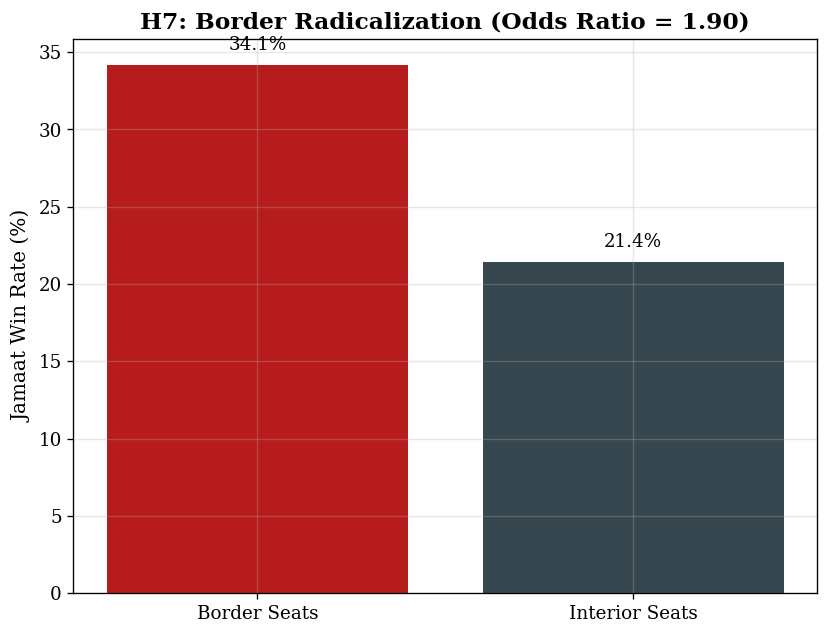

In [ ]:
print("=" * 80)
print("H7: GEOSPATIAL BORDER RADICALIZATION")
print("=" * 80)

BORDER_DISTRICTS = ["Panchagarh", "Thakurgaon", "Dinajpur", "Nilphamari", "Lalmonirhat", "Kurigram",
                    "Naogaon", "Chapainawabganj", "Rajshahi", "Natore", "Nawabganj", "Meherpur",
                    "Kushtia", "Chuadanga", "Jhenaidah", "Jashore", "Jessore", "Satkhira", "Khulna",
                    "Bagerhat", "Sherpur", "Jamalpur", "Mymensingh", "Netrokona", "Kishoreganj",
                    "Brahmanbaria", "Sunamganj", "Sylhet", "Moulvibazar", "Habiganj", "Comilla",
                    "Feni", "Khagrachari", "Rangamati"]

def extract_district(c_name):
    if c_name:
        d = str(c_name).rsplit("-", 1)[0].strip()
        return d.rsplit(" ", 1)[0] if d[-1:].isdigit() else d
    return ""

clf_pdf["District"] = clf_pdf["Constituency"].apply(extract_district)
clf_pdf["Border_Proximity"] = clf_pdf["District"].apply(lambda d: 1 if any(bd.lower() in d.lower() for bd in BORDER_DISTRICTS) else 0)

border = clf_pdf[clf_pdf["Border_Proximity"] == 1]
interior = clf_pdf[clf_pdf["Border_Proximity"] == 0]

jam_b = (border["Coalition"] == "JAMAAT_REFORM").sum()
jam_i = (interior["Coalition"] == "JAMAAT_REFORM").sum()

p1 = jam_b / len(border) if len(border) > 0 else 0
p2 = jam_i / len(interior) if len(interior) > 0 else 0

print(f"Border Jamaat Win Rate: {p1*100:.1f}%")
print(f"Interior Jamaat Win Rate: {p2*100:.1f}%")

# Odds Ratio
a = jam_b; b = len(border) - jam_b
c = jam_i; d = len(interior) - jam_i
odds_ratio = (a * d) / (b * c) if (b * c) > 0 else float('inf')
print(f"Odds Ratio: {odds_ratio:.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(["Border Seats", "Interior Seats"], [p1*100, p2*100], color=[PALETTE_JAMAAT, PALETTE_NEUTRAL])
ax.set_ylabel("Jamaat Win Rate (%)")
ax.set_title(f"H7: Border Radicalization (Odds Ratio = {odds_ratio:.2f})")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', ha='center')
plt.show()

## Hypothesis 8: The Coalition Referendum Cleavage
**Premise**: The BNP alliance actively preferred the "NO" referendum vote, while the Jamaat/NCP alliance weaponized the "YES" vote, indicating the referendum functioned as a proxy for partisan loyalties.
**Methodology**: Independent t-tests and Logistic Regression mapping coalition outcomes to majority referendum outcomes.


H8: THE COALITION REFERENDUM CLEAVAGE
BNP Mean NO_Pct: 34.62%
Jamaat Mean NO_Pct: 29.44%
T-test p-value: 0.000781


/tmp/ipykernel_3883/2604247727.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ref_clf, x="Coalition", y="NO_Pct", palette=[PALETTE_BNP, PALETTE_JAMAAT], ax=ax)


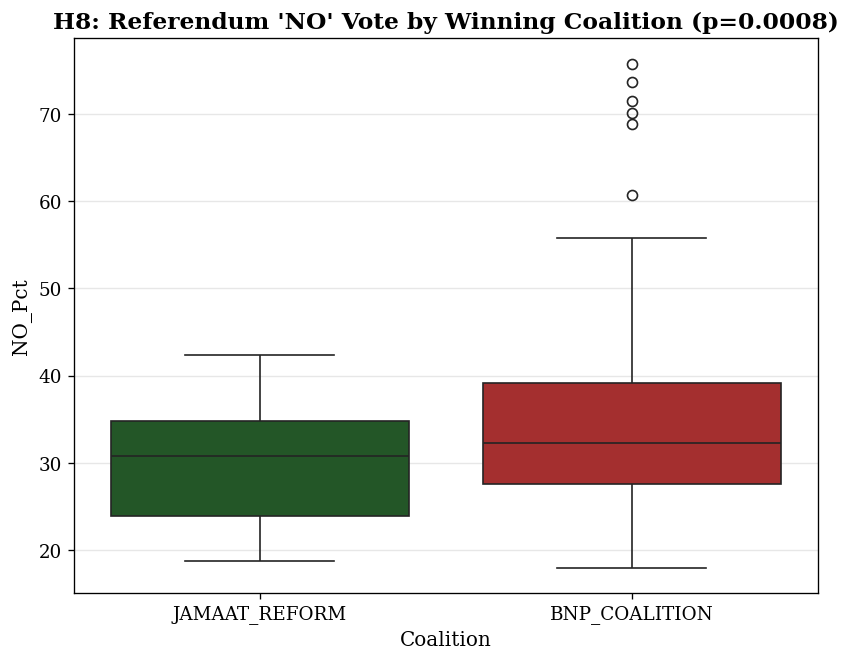

In [ ]:
print("=" * 80)
print("H8: THE COALITION REFERENDUM CLEAVAGE")
print("=" * 80)

ref_clf = grand_df_enriched.filter(F.col("Coalition").isin(["BNP_COALITION", "JAMAAT_REFORM"])).dropna(subset=["YES_Pct", "NO_Pct"]).toPandas()

bnp_no = ref_clf[ref_clf["Coalition"] == "BNP_COALITION"]["NO_Pct"]
jam_no = ref_clf[ref_clf["Coalition"] == "JAMAAT_REFORM"]["NO_Pct"]
t_stat, p_val = stats.ttest_ind(bnp_no, jam_no, equal_var=False)

print(f"BNP Mean NO_Pct: {bnp_no.mean():.2f}%")
print(f"Jamaat Mean NO_Pct: {jam_no.mean():.2f}%")
print(f"T-test p-value: {p_val:.6f}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=ref_clf, x="Coalition", y="NO_Pct", palette=[PALETTE_BNP, PALETTE_JAMAAT], ax=ax)
ax.set_title(f"H8: Referendum 'NO' Vote by Winning Coalition (p={p_val:.4f})")
plt.show()

## Hypothesis 9: The Digital Referendum Paradox
**Premise**: High internet penetration serves as a primary vector for pro-reform constitutional changes ("YES"), independent of youth demographics.
**Methodology**: Multimodal correlations and Linear Regression predicting `YES_Pct` controlling for `Youth_Electorate_Pct`.


H9: THE DIGITAL REFERENDUM PARADOX
Pearson Correlation (Internet vs YES): 0.0952
Regression Coeffs predicting YES_Pct -> Internet: 0.1390, Youth: -0.2345


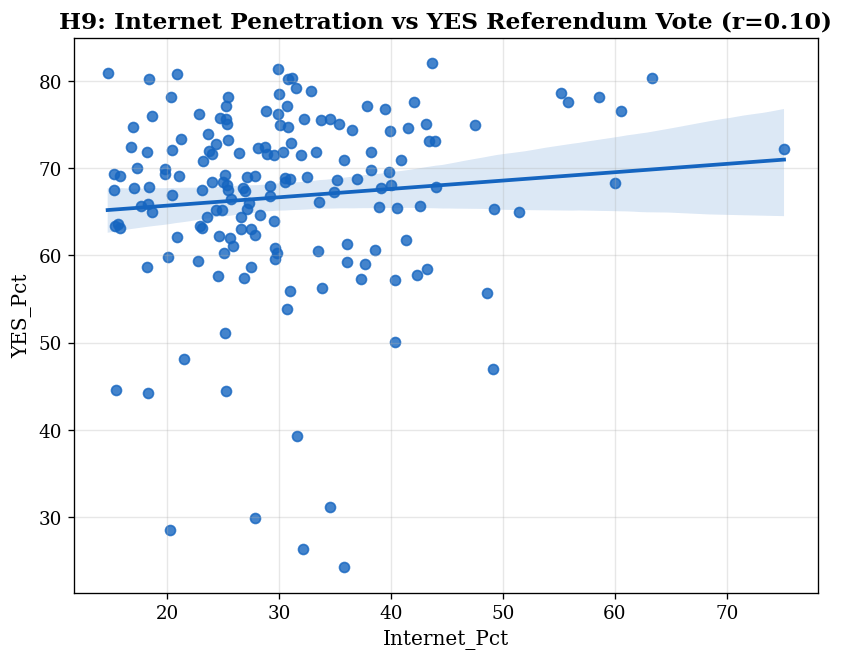

In [ ]:
print("=" * 80)
print("H9: THE DIGITAL REFERENDUM PARADOX")
print("=" * 80)

# FIX: Create a dedicated dataframe extracting the necessary columns from the source
ref_df_h9 = grand_df_enriched.select("Internet_Pct", "Youth_Electorate_Pct", "YES_Pct").dropna()
ref_pdf_h9 = ref_df_h9.toPandas()

corr_int_yes = ref_pdf_h9["Internet_Pct"].corr(ref_pdf_h9["YES_Pct"])
print(f"Pearson Correlation (Internet vs YES): {corr_int_yes:.4f}")

assembler_h9 = VectorAssembler(inputCols=["Internet_Pct", "Youth_Electorate_Pct"], outputCol="features_h9")
lr_h9 = LinearRegression(featuresCol="features_h9", labelCol="YES_Pct")
pipe_h9 = Pipeline(stages=[assembler_h9, lr_h9])
model_h9 = pipe_h9.fit(ref_df_h9)

coeffs_h9 = model_h9.stages[-1].coefficients
print(f"Regression Coeffs predicting YES_Pct -> Internet: {coeffs_h9[0]:.4f}, Youth: {coeffs_h9[1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=ref_pdf_h9, x="Internet_Pct", y="YES_Pct", color=PALETTE_ACCENT, ax=ax)
ax.set_title(f"H9: Internet Penetration vs YES Referendum Vote (r={corr_int_yes:.2f})")
plt.show()


## Hypothesis 10: The Poverty Anti-Reform Backlash
**Premise**: Highly impoverished demographics systematically voted "NO" on the referendum, prioritizing establishment stability over systemic constitutional changes.
**Methodology**: Correlation analysis and GBT Regressor modeling `NO_Pct` to identify absolute poverty threshold rejections.


H10: THE POVERTY ANTI-REFORM BACKLASH
Pearson Correlation (Extreme Poverty vs NO): 0.0816


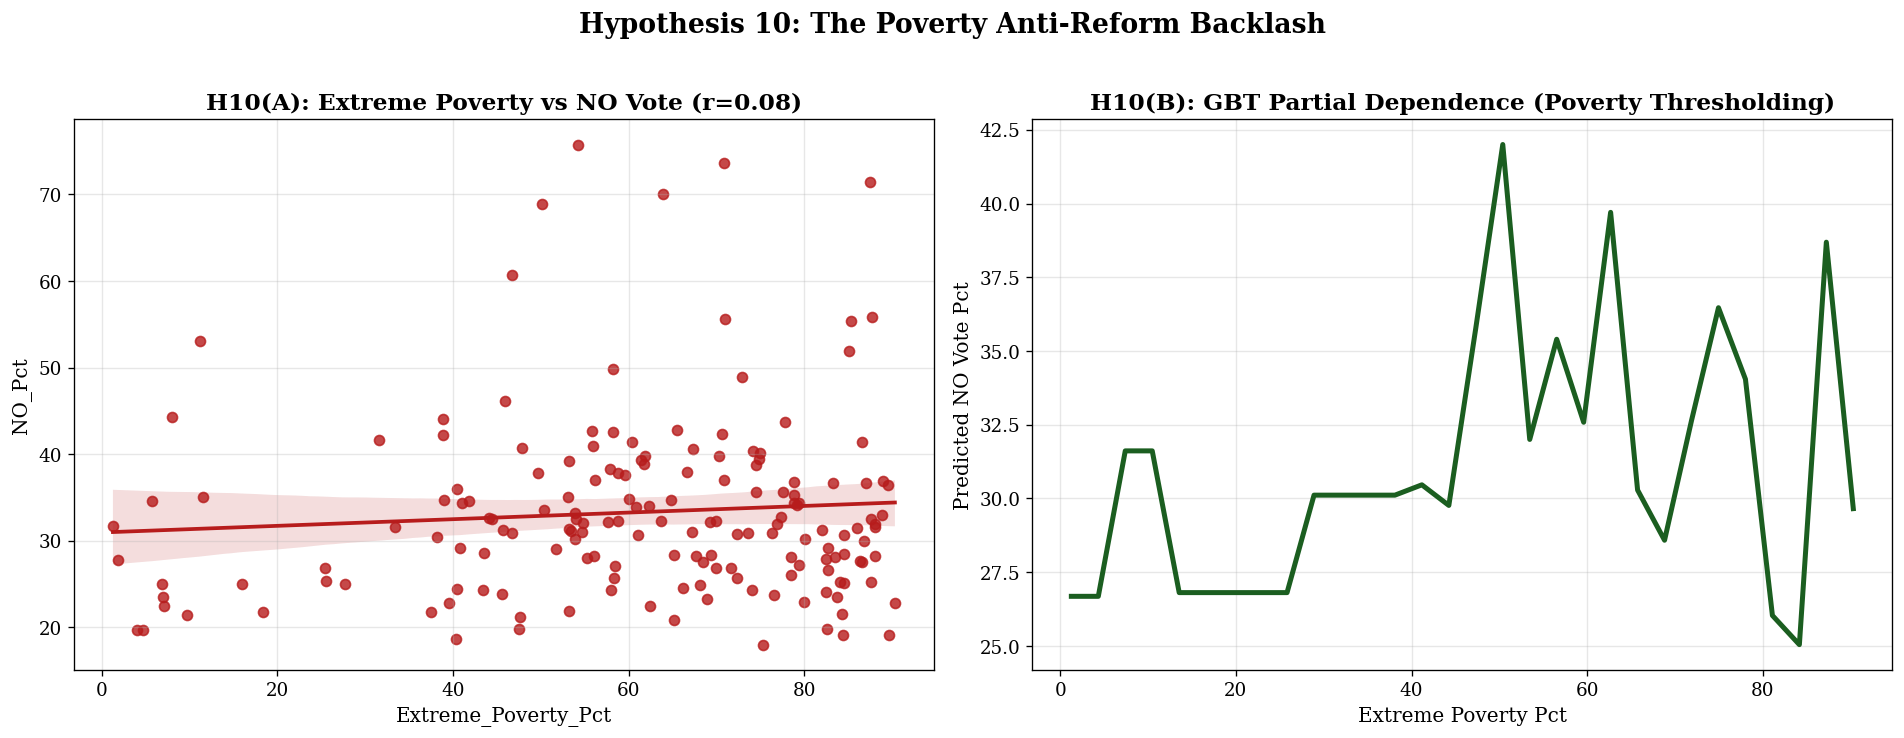

Phase 5 Deductive Hypothesis Testing Complete.


In [ ]:
print("=" * 80)
print("H10: THE POVERTY ANTI-REFORM BACKLASH")
print("=" * 80)

# FIX: Create a dedicated dataframe extracting the necessary columns from the source
ref_df_h10 = grand_df_enriched.select("Extreme_Poverty_Pct", "NO_Pct").dropna()
ref_pdf_h10 = ref_df_h10.toPandas()

corr_pov_no = ref_pdf_h10["Extreme_Poverty_Pct"].corr(ref_pdf_h10["NO_Pct"])
print(f"Pearson Correlation (Extreme Poverty vs NO): {corr_pov_no:.4f}")

assembler_h10 = VectorAssembler(inputCols=["Extreme_Poverty_Pct"], outputCol="features_h10")
gbt_r = GBTRegressor(featuresCol="features_h10", labelCol="NO_Pct", maxIter=50)
pipe_h10 = Pipeline(stages=[assembler_h10, gbt_r])
model_h10 = pipe_h10.fit(ref_df_h10)

pov_range = np.linspace(ref_pdf_h10["Extreme_Poverty_Pct"].min(), ref_pdf_h10["Extreme_Poverty_Pct"].max(), 30)
pd_pov = []
for val in pov_range:
    temp_df = spark.createDataFrame([{"Extreme_Poverty_Pct": float(val)}])
    temp_df = temp_df.withColumn("Extreme_Poverty_Pct", F.col("Extreme_Poverty_Pct").cast(DoubleType()))
    pred = model_h10.transform(temp_df).select("prediction").head()[0]
    pd_pov.append(pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(data=ref_pdf_h10, x="Extreme_Poverty_Pct", y="NO_Pct", color=PALETTE_JAMAAT, ax=axes[0])
axes[0].set_title(f"H10(A): Extreme Poverty vs NO Vote (r={corr_pov_no:.2f})")

axes[1].plot(pov_range, pd_pov, color=PALETTE_BNP, linewidth=3)
axes[1].set_xlabel("Extreme Poverty Pct")
axes[1].set_ylabel("Predicted NO Vote Pct")
axes[1].set_title("H10(B): GBT Partial Dependence (Poverty Thresholding)")

plt.suptitle("Hypothesis 10: The Poverty Anti-Reform Backlash", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Phase 5 Deductive Hypothesis Testing Complete.")
